# Question 1

## How many tennis players are included in the dataset? 


This script answers the main question, then draws two DIFFERENT pie
charts that look similar but answer two different sub-questions.
in singles tennis, "home"/"away" is not a real home
court -- it's just a display convention (e.g. based on seeding or
alphabetical order). If Chart 2 shows many players who are ALWAYS home
or ALWAYS away, that hints at a hidden systematic rule behind the
home/away labeling (e.g. "the higher-seeded player is always listed as
home")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"

home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")

In [2]:
print(f"Home team appearances: {len(home)}")
print(f"Away team appearances: {len(away)}")

players_long = pd.concat([home, away], ignore_index=True)
print(f"Total player appearances (home + away): {len(players_long)}")

missing_id = players_long["player_id"].isna().sum()
print(f"Appearances with missing player_id: {missing_id}")

n_players = players_long["player_id"].nunique()
avg_appearances = (len(players_long) - missing_id) / n_players

print(f"\nAnswer to Question 1 -- unique players in the dataset: {n_players}")
print(f"On average, each player appears in about {avg_appearances:.1f} matches "
      f"(as home or away combined).")

Home team appearances: 12389
Away team appearances: 11690
Total player appearances (home + away): 24079
Appearances with missing player_id: 0

Answer to Question 1 -- unique players in the dataset: 2644
On average, each player appears in about 9.1 matches (as home or away combined).


### =======================================================================
### Chart 1 -- Share of APPEARANCES (rows) that were Home vs Away
### Goal: a simple structural sanity check on the raw data, not the players.
### =======================================================================

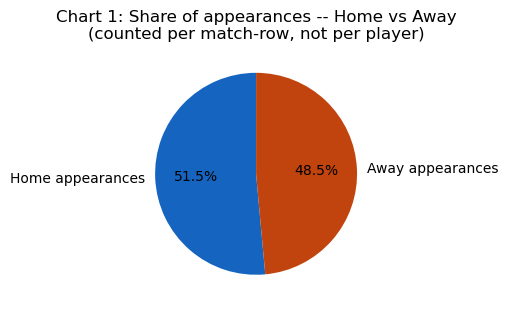

In [3]:
plt.figure(figsize=(5, 5))
plt.pie(
    [len(home), len(away)],
    labels=["Home appearances", "Away appearances"],
    autopct="%1.1f%%",
    colors=["#1565c0", "#c1440e"],
    startangle=90,
)
plt.title("Chart 1: Share of appearances -- Home vs Away\n(counted per match-row, not per player)")
plt.tight_layout()
plt.savefig('charts/q1_Share of appearances, counted per match-row.png', dpi=200)
plt.show()

### =======================================================================
### Chart 2 -- Share of UNIQUE PLAYERS who are Home-only, Away-only, or Both
### Goal: reveal whether home/away labeling follows a hidden per-player
### pattern (e.g. always the higher seed), which Chart 1 cannot show.
### =======================================================================


Players who were ALWAYS home: 165
Players who were ALWAYS away: 197
Players who appeared as BOTH home and away: 2282


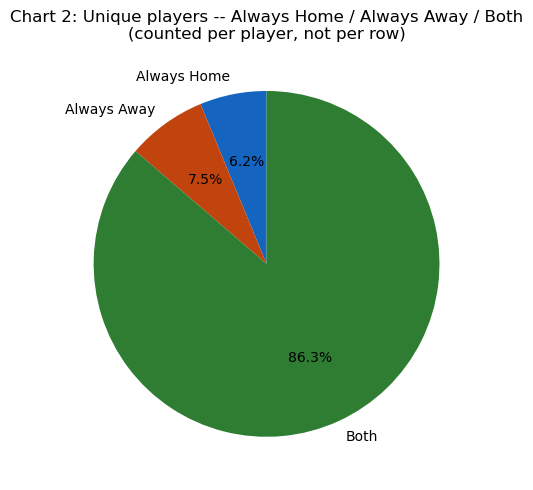

In [4]:
home_ids = set(home["player_id"].dropna())
away_ids = set(away["player_id"].dropna())

home_only = home_ids - away_ids
away_only = away_ids - home_ids
both_sides = home_ids & away_ids

print(f"\nPlayers who were ALWAYS home: {len(home_only)}")
print(f"Players who were ALWAYS away: {len(away_only)}")
print(f"Players who appeared as BOTH home and away: {len(both_sides)}")

plt.figure(figsize=(5, 5))
plt.pie(
    [len(home_only), len(away_only), len(both_sides)],
    labels=["Always Home", "Always Away", "Both"],
    autopct="%1.1f%%",
    colors=["#1565c0", "#c1440e", "#2e7d32"],
    startangle=90,
)
plt.title("Chart 2: Unique players -- Always Home / Always Away / Both\n(counted per player, not per row)")
plt.tight_layout()
plt.savefig('charts/q1_Unique players, counted per player.png', dpi=200)
plt.show()


### Follow-up check: is "Always Home" / "Always Away" just a random-chance
### artifact of players with very few appearances, or a real pattern that
### persists even for players with many matches?


In [5]:
appearance_counts = players_long["player_id"].value_counts()

def label_group(pid):
    if pid in home_only:
        return "Always Home"
    elif pid in away_only:
        return "Always Away"
    else:
        return "Both"

group_df = appearance_counts.rename("n_appearances").reset_index()
group_df.columns = ["player_id", "n_appearances"]
group_df["group"] = group_df["player_id"].apply(label_group)

print(group_df.groupby("group")["n_appearances"].describe())

              count       mean       std  min  25%   50%   75%   max
group                                                               
Always Away   197.0   2.294416  1.598666  1.0  1.0   2.0   3.0   9.0
Always Home   165.0   3.145455  2.716828  1.0  1.0   2.0   4.0  18.0
Both         2282.0  10.126205  4.952543  2.0  6.0  10.0  13.0  36.0


### How many "Always Home"/"Always Away" players have MORE than a couple
### of appearances -- these are the ones a coincidence can't easily explain

In [6]:
suspicious = group_df[
    (group_df["group"] != "Both") & (group_df["n_appearances"] >= 5)
]
print(f"\n'Always Home/Away' players with 5+ appearances "
      f"(too many to be a coincidence): {len(suspicious)}")
print(suspicious.sort_values("n_appearances", ascending=False).head(10))


'Always Home/Away' players with 5+ appearances (too many to be a coincidence): 52
      player_id  n_appearances        group
152      228272             18  Always Home
661       47876             13  Always Home
603       49417             13  Always Home
711       25683             12  Always Home
866      355540             11  Always Home
1038     221515             10  Always Home
1084     417332             10  Always Home
1163     229246             10  Always Home
1181     253830              9  Always Away
1188     177644              9  Always Away


### Visual comparison: distribution of appearance counts per group

<Figure size 700x500 with 0 Axes>

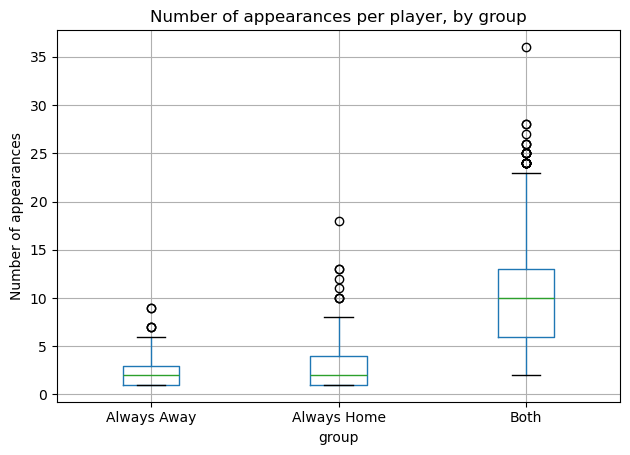

In [7]:
plt.figure(figsize=(7, 5))
group_df.boxplot(column="n_appearances", by="group")
plt.title("Number of appearances per player, by group")
plt.suptitle("")
plt.ylabel("Number of appearances")
plt.tight_layout()
plt.savefig('charts/q1_Number of appearances per player, by group.png', dpi=200)
plt.show()

### =======================================================================
### FINDINGS SUMMARY -- Question 1 (and a side discovery along the way)
### =======================================================================

#### Question 1: How many unique tennis players are in the dataset?
#### Answer: 2,644 unique players (from 24,079 total home/away appearances
#### across 16,873 matches). On average, each player appears in about 9.1 matches.

### =======================================================================
#### Side investigation: is the "home"/"away" label meaningful for players,
#### or just a random display convention?
### =======================================================================

Step 1 -- Row-level check (Chart 1):
Appearances split almost evenly: 51.5% home vs 48.5% away. No bias at
the raw-data level.

Step 2 -- Player-level check (Chart 2):
Of the 2,644 unique players, 86.3% (2,282) appeared on both sides at
some point, 7.5% (197) were always "away", and 6.2% (165) were always
"home". At first glance, the 13.7% who were always on one side looked
like a possible hidden rule in how the source data assigns home/away.

Step 3 -- Statistical follow-up:
Grouped players by number of appearances. The median player in both
"Always Home" and "Always Away" groups had only 2 total appearances,
versus a median of 10 for players who appeared on both sides. This
means most of the 13.7% are explained by ordinary chance: a player
with only 1-2 matches has a high probability of landing on the same
side every time even under purely random assignment.

However, 52 players had 5 or more appearances while still always
being on one side -- far too many to be explained by chance (e.g. a
player with 18 appearances, always "home", has under a 0.001%
probability of that happening randomly).

Conclusion:
The home/away label is effectively random for the vast majority of
players, BUT a small subgroup (52 of 2,644 players, ~2%) shows a
statistically significant, systematic pattern of always being
assigned to one side. This is likely a rule in the source data's
labeling convention (e.g. based on ranking or seeding at the time),
not a data quality error.